![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    XGBoost gap-filling
</b>: extensive example, more parameters
</span>

---
**Notebook version**: `1` (26 Apr 2024)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)  

</br>

# **Background**

- Using [XGBoost](https://xgboost.readthedocs.io/en/stable/) to gap-fill time series data

</br>

# **User settings**
`TARGET_COL` ... name of the time series that is gap-filled  
`subsetcols` ... list of columns included in the random forest model, target must also be listed here

All columns that are not the target will be used as features/predictors during model building.

In [1]:
TARGET_COL = 'NEE_CUT_REF_orig'
subsetcols = [TARGET_COL, 'Tair_f', 'VPD_f', 'Rg_f', 'SWC_FF0_0.15_1', 'PPFD']

</br>

# **Imports**
- This notebook uses `diive` ([source code](https://gitlab.ethz.ch/diive/diive)) to check eddy covariance fluxes for quality

In [2]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np

from diive.configs.exampledata import load_exampledata_parquet
from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.pkgs.createvar.daynightflag import DaytimeNighttimeFlag
from diive.pkgs.createvar.timesince import TimeSince
from diive.pkgs.gapfilling.xgboost_ts import XGBoostTS

warnings.filterwarnings('ignore')
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

# **Docstring** for `XGBoostTS`

In [3]:
# help(XGBoostTS)

</br>

---

# **Load data**

## Load example data from parquet file

In [4]:
source_df = load_exampledata_parquet()

Loaded .parquet file F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\configs\exampledata\exampledata_PARQUET_CH-DAV_FP2022.5_2013-2022_ID20230206154316_30MIN.parquet (0.047 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


## Make subset

In [5]:
df = source_df.copy()
lowquality = df[
                 "QCF_NEE"] > 0  # This example uses NEE flux data, only records where the quality flag QCF is 0 (highest quality) are retained
df.loc[lowquality, TARGET_COL] = np.nan  # Set fluxes of lower quality to missing
df = df[subsetcols].copy()  # Keep subset columns only

## Add more features

In [6]:
# Calculate time since sub-zero air temperature
ts = TimeSince(df['Tair_f'], upper_lim=0, include_lim=True)
ts.calc()
ts_series = ts.get_timesince()
df['TA>0'] = ts_series

# Calculate time since air temperature was >= 20°C
ts = TimeSince(df['Tair_f'], lower_lim=20, include_lim=True)
ts.calc()
ts_series = ts.get_timesince()
# xxx = ts.get_full_results()
df['TA>20'] = ts_series

# Calculate daytime and nighttime flag
dnf = DaytimeNighttimeFlag(
    timestamp_index=df.index,
    nighttime_threshold=50,
    lat=46.815333,
    lon=9.855972,
    utc_offset=1)
results = dnf.get_results()
df['DAYTIME'] = results['DAYTIME'].copy()
df['NIGHTTIME'] = results['NIGHTTIME'].copy()

In [7]:
df

,NEE_CUT_REF_orig,Tair_f,VPD_f,Rg_f,SWC_FF0_0.15_1,PPFD,TA>0,TA>20,DAYTIME,NIGHTTIME
TIMESTAMP_MIDDLE,,,,,,,,,,
2013-01-01 00:15:00,NaN,-1.618,1.339,0.0,34.977,0.017,0,1,0.0,1.0
2013-01-01 00:45:00,NaN,-1.630,1.337,0.0,34.977,0.031,0,2,0.0,1.0
2013-01-01 01:15:00,NaN,-1.644,1.335,0.0,34.971,-0.006,0,3,0.0,1.0
2013-01-01 01:45:00,0.538,-1.657,1.332,0.0,34.975,-0.018,0,4,0.0,1.0
2013-01-01 02:15:00,NaN,-0.567,3.545,0.0,34.967,0.007,0,5,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
2022-12-31 21:45:00,NaN,3.463,2.210,0.0,19.572,0.000,71,5241,0.0,1.0
2022-12-31 22:15:00,3.518,5.283,3.327,0.0,19.577,0.000,72,5242,0.0,1.0
2022-12-31 22:45:00,NaN,5.537,3.467,0.0,19.589,0.000,73,5243,0.0,1.0


In [8]:
df.describe()

,NEE_CUT_REF_orig,Tair_f,VPD_f,Rg_f,SWC_FF0_0.15_1,PPFD,TA>0,TA>20,DAYTIME,NIGHTTIME
count,41284.000000,175296.000000,175296.000000,175296.000000,164568.000000,175060.000000,175296.000000,175296.000000,175296.000000,175296.000000
mean,-3.833522,4.712999,3.233176,152.671445,23.909444,305.280529,1210.571211,4501.219229,0.480969,0.519031
std,6.085449,7.548653,3.710180,247.531312,4.890167,494.128310,1860.740670,4086.748021,0.499639,0.499639
min,-38.653000,-23.096000,0.000000,0.000000,12.436000,-2.707000,0.000000,0.000000,0.000000,0.000000
25%,-7.840000,-0.800000,0.661000,0.000000,20.748000,0.000000,0.000000,430.000000,0.000000,0.000000
50%,-3.827000,4.600000,1.991000,2.596000,24.496000,9.721000,119.000000,3655.000000,0.000000,1.000000
75%,0.606250,10.067000,4.375000,225.677750,27.106000,449.168500,1895.000000,7881.250000,1.000000,1.000000
max,25.290000,28.713000,32.118000,1197.800000,41.451000,2420.772000,7853.000000,13386.000000,1.000000,1.000000


In [9]:
sstats(df[TARGET_COL])

,NEE_CUT_REF_orig
STARTDATE,2013-01-01 00:15
ENDDATE,2022-12-31 23:45
PERIOD,3651 days 23:30:00
NOV,41284
MISSING,134012
MISSING_PERC,76.448978
MEAN,-3.833522
MEDIAN,-3.827
SD,6.085449
VAR,37.032694


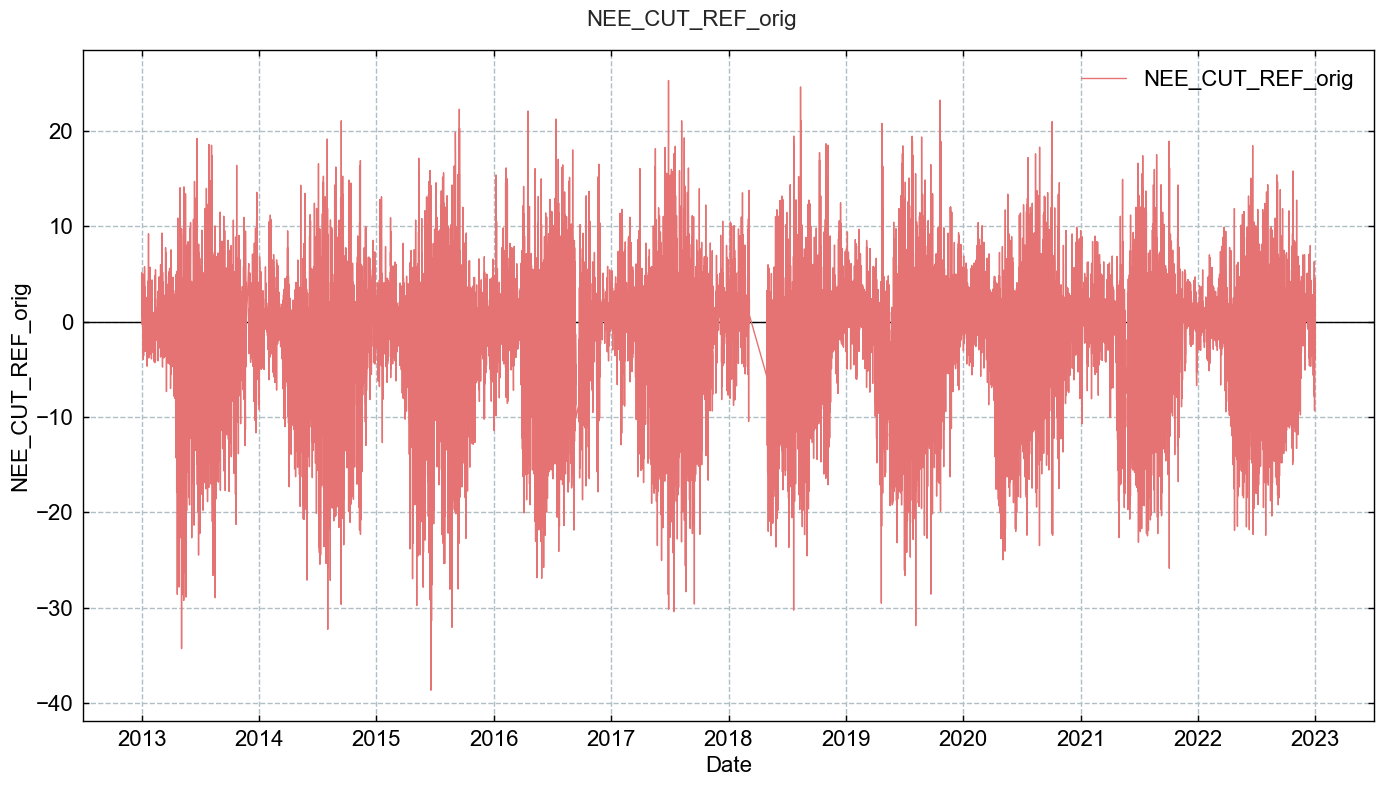

In [10]:
# TimeSeries(series=df[TARGET_COL]).plot_interactive()
TimeSeries(series=df[TARGET_COL]).plot()

</br>

</br>

# **Gap-filling**

## Initialize XGBoost

In [11]:
xgbts = XGBoostTS(
    input_df=df,
    target_col=TARGET_COL,
    verbose=1,
    features_lag=[-1, -1],
    features_lag_stepsize=1,
    features_lag_exclude_cols=['Rg_f', 'TA>0', 'TA>20', 'DAYTIME', 'NIGHTTIME'],
    features_rolling=[12, 24],
    features_rolling_exclude_cols=None,
    features_rolling_stats=['median', 'min', 'max', 'std', 'q25', 'q75'],
    features_diff=[1, 2],
    features_diff_exclude_cols=None,
    features_poly_degree=2,
    features_poly_exclude_cols=None,
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=True,
    n_estimators=99,
    random_state=42,
    validate_parameters=True,
    early_stopping_rounds=10,
    max_depth=6,
    learning_rate=0.3,
    tree_method='auto',
    n_jobs=-1
)



Starting gap-filling for
NEE_CUT_REF_orig
using <class 'xgboost.sklearn.XGBRegressor'>

Adding new data columns ...
++ Added new columns with lagged variants for: ['Tair_f', 'VPD_f', 'SWC_FF0_0.15_1', 'PPFD'] (lags between -1 and -1 with stepsize 1), no lagged variants for: ['NEE_CUT_REF_orig', 'Rg_f', 'TA>0', 'TA>20', 'DAYTIME', 'NIGHTTIME']. Shifting the time series created gaps which were then filled with the nearest value.
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 175296.

Sanitizing timestamp ...
>>> Validating timestamp naming of timestamp column TIMESTAMP_MIDDLE ... Timestamp name OK.
>>> Converting timestamp TIMESTAMP_MIDDLE to datetime ... OK
>>> All rows have timestamp TIMESTAMP_MIDDL

</br>

## Feature reduction

In [12]:
xgbts.reduce_features()


[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:4.92536	validation_1-rmse:4.92536
[1]	validation_0-rmse:4.21802	validation_1-rmse:4.21802
[2]	validation_0-rmse:3.78930	validation_1-rmse:3.78930
[3]	validation_0-rmse:3.54196	validation_1-rmse:3.54196
[4]	validation_0-rmse:3.38869	validation_1-rmse:3.38869
[5]	validation_0-rmse:3.29107	validation_1-rmse:3.29107
[6]	validation_0-rmse:3.22721	validation_1-rmse:3.22721
[7]	validation_0-rmse:3.18035	validation_1-rmse:3.18035
[8]	validation_0-rmse:3.14139	validation_1-rmse:3.14139
[9]	validation_0-rmse:3.11442	validation_1-rmse:3.11442
[10]	validation_0-rmse:3.08288	validation_1-rmse:3.08288
[11]	validation_0-rmse:3.05926	validation_1-rmse:3.05926
[12]	validation_0-rmse:3.03987	validation_1-rmse:3.03987
[13]	validation_0-rmse:3.02240	validation_1-rmse:3.02240
[14]	validation_0-rmse:3.00563	validation_1-rmse:3.00563
[15]	validation_0-rmse:2.99461	validation_1-rmse:2.99461
[16]	validation_0-rms

In [13]:
xgbts.report_feature_reduction()


FEATURE REDUCTION

- Target variable: NEE_CUT_REF_orig

- The random variable .RANDOM was added to the original features, used as benchmark for detecting relevant feature importances.

PERMUTATION IMPORTANCE (mean) across all splits of TimeSeriesSplit:

                   PERM_IMPORTANCE   PERM_SD
PPFD                      0.569436  0.003739
Rg_f                      0.300630  0.001477
.Tair_f-1                 0.258572  0.002258
.VPD_f-1                  0.241383  0.003095
.DOY_COS                  0.136796  0.001667
Tair_f                    0.136032  0.001763
.PPFD-1                   0.116557  0.001945
TA>0                      0.085884  0.001047
VPD_f                     0.083007  0.000811
.DOY_SIN                  0.067341  0.001598
TA>20                     0.057206  0.000736
SWC_FF0_0.15_1            0.055714  0.000962
.HOUR_SIN                 0.053707  0.000804
.YEARDOY                  0.041116  0.000597
.YEARWEEK                 0.027702  0.000508
.SWC_FF0_0.15_1-1        

</br>

## Train model


Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2013-01-01 01:45:00 and 2022-12-31 22:15:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:4.92483	validation_1-rmse:4.93607
[1]	validation_0-rmse:4.21542	validation_1-rmse:4.24116
[2]	validation_0-rmse:3.79508	validation_1-rmse:3.83257
[3]	validation_0-rmse:3.53728	validation_1-rmse:3.59019
[4]	validation_0-rmse:3.38692	validation_1-rmse:3.45542
[5]	validation_0-rmse:3.29359	validation_1-rmse:3.36965
[6]	validation_0-rmse:3.23326	validation_1-rmse:3.32131
[7]	validation_0-rmse:3.18745	validation_1-rmse:3.29648
[8]	validation_0-rmse:3.15307	validation_1-rmse:3.27710
[9]	validation_0-rmse:3.12809	validation_1-rmse:3.26447
[10]	validation_0-rmse:3.10593	validation_1-rmse:3.25019
[11]	validation_0-rmse:3.08434	validation_1-rmse:3.24094
[12]	validation_0-rmse:3.06215	validation_1-rmse:3.23348
[13]	validation_0-rmse:3.04756	validation_1-rmse:3.23113
[14]	validation_0-r

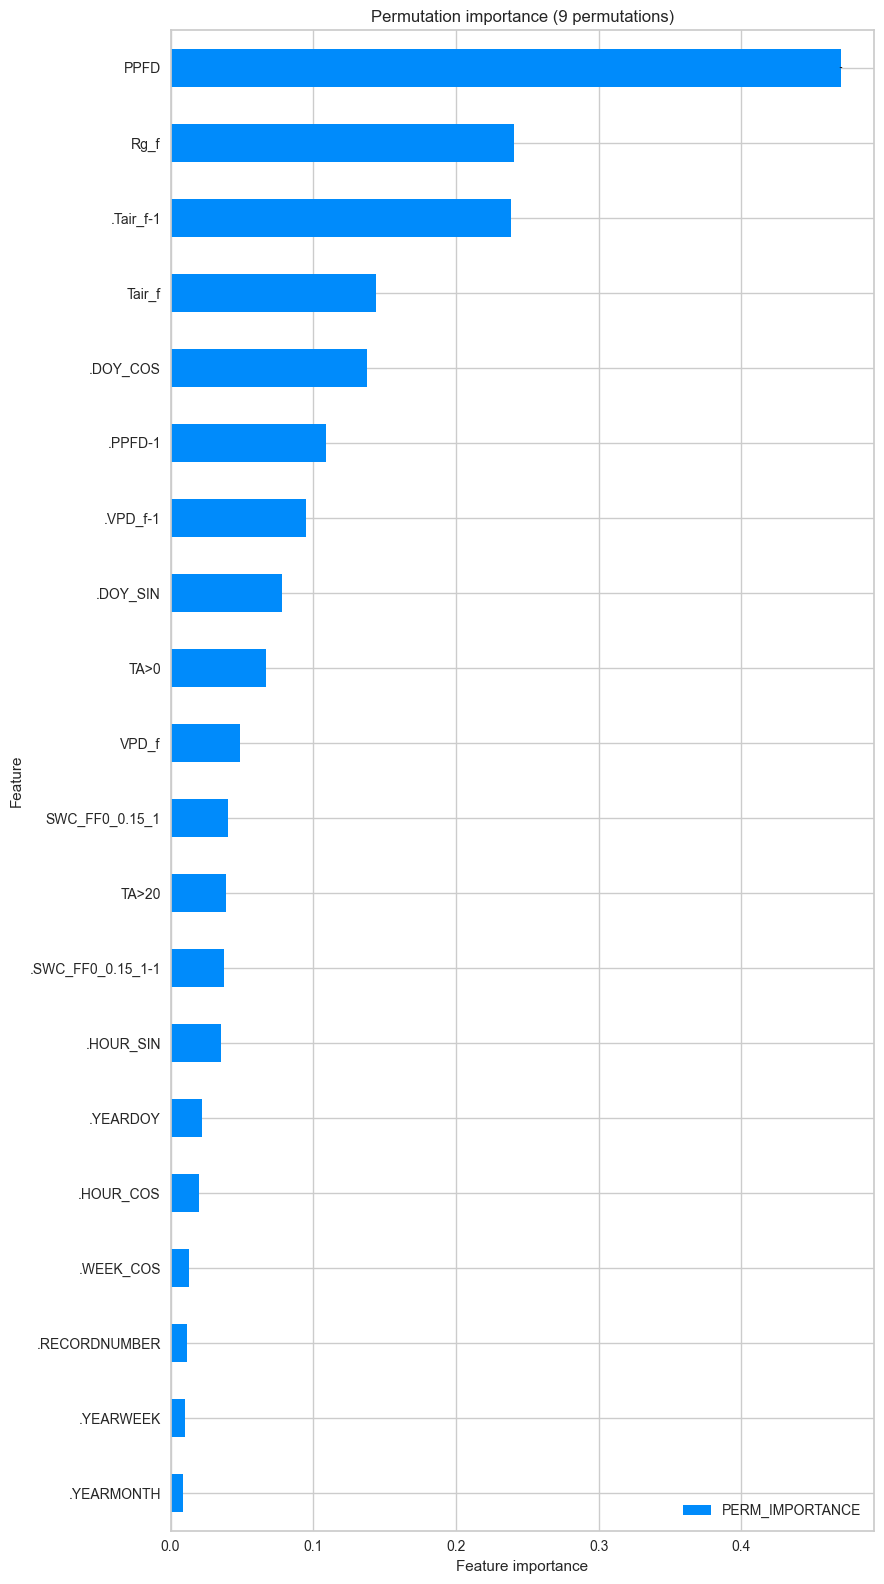

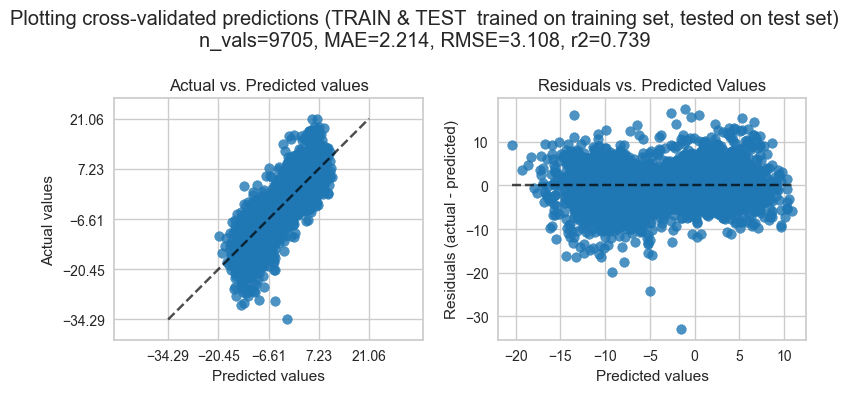

>>> Plotting residuals and prediction error ...


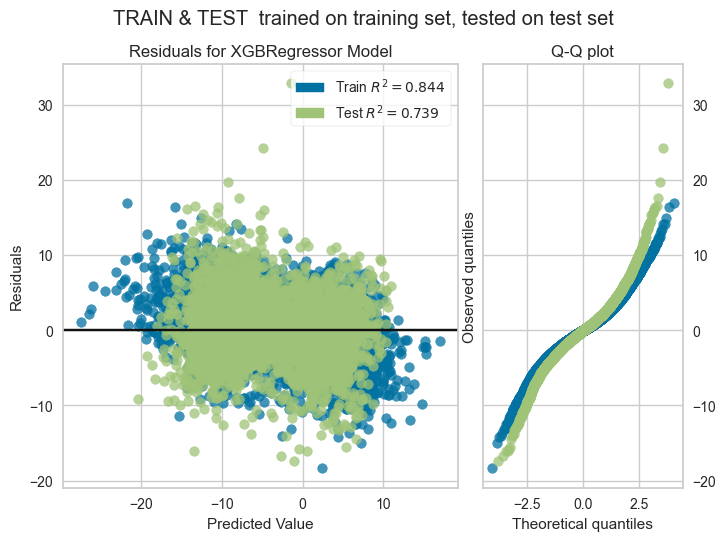

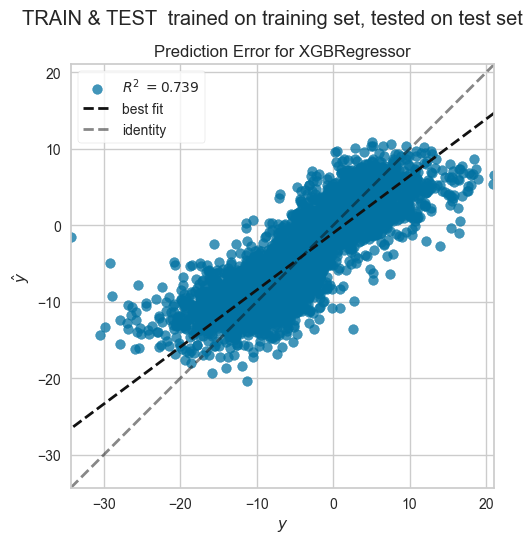

>>> Collecting results, details about training and testing can be accessed by calling .report_traintest().
>>> Done.


In [14]:
xgbts.trainmodel(showplot_scores=True, showplot_importance=True)

In [15]:
xgbts.report_traintest()


MODEL TRAINING & TESTING RESULTS

## DATA
  > target: NEE_CUT_REF_orig
  > features: 20 ['PPFD', 'Rg_f', '.Tair_f-1', '.VPD_f-1', '.DOY_COS', 'Tair_f', '.PPFD-1', 'TA>0', 'VPD_f', '.DOY_SIN', 'TA>20', 'SWC_FF0_0.15_1', '.HOUR_SIN', '.YEARDOY', '.YEARWEEK', '.SWC_FF0_0.15_1-1', '.HOUR_COS', '.RECORDNUMBER', '.YEARMONTH', '.WEEK_COS']
  > 175296 records (with missing)
  > 38820 available records for target and all features (no missing values)
  > training on 29115 records (75.0%) of 29115 features between 2013-01-01 01:45:00 and 2022-12-31 22:15:00
  > testing on 9705 unseen records (25.0%) of NEE_CUT_REF_orig between 2013-01-02 12:15:00 and 2022-12-31 13:15:00

## MODEL
  > the model was trained on training data (29115 records)
  > the model was tested on test data (9705 values)
  > estimator:  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,

</br>

## Apply model to fill gaps


Gap-filling using final model ...
>>> Using final model on all data to predict target NEE_CUT_REF_orig ...
>>> Using final model on all data to calculate permutation importance ...
>>> Plotting feature importances (permutation importance) ...
>>> Calculating prediction scores based on all data predicting NEE_CUT_REF_orig ...
>>> Plotting observed and predicted values based on all data ...


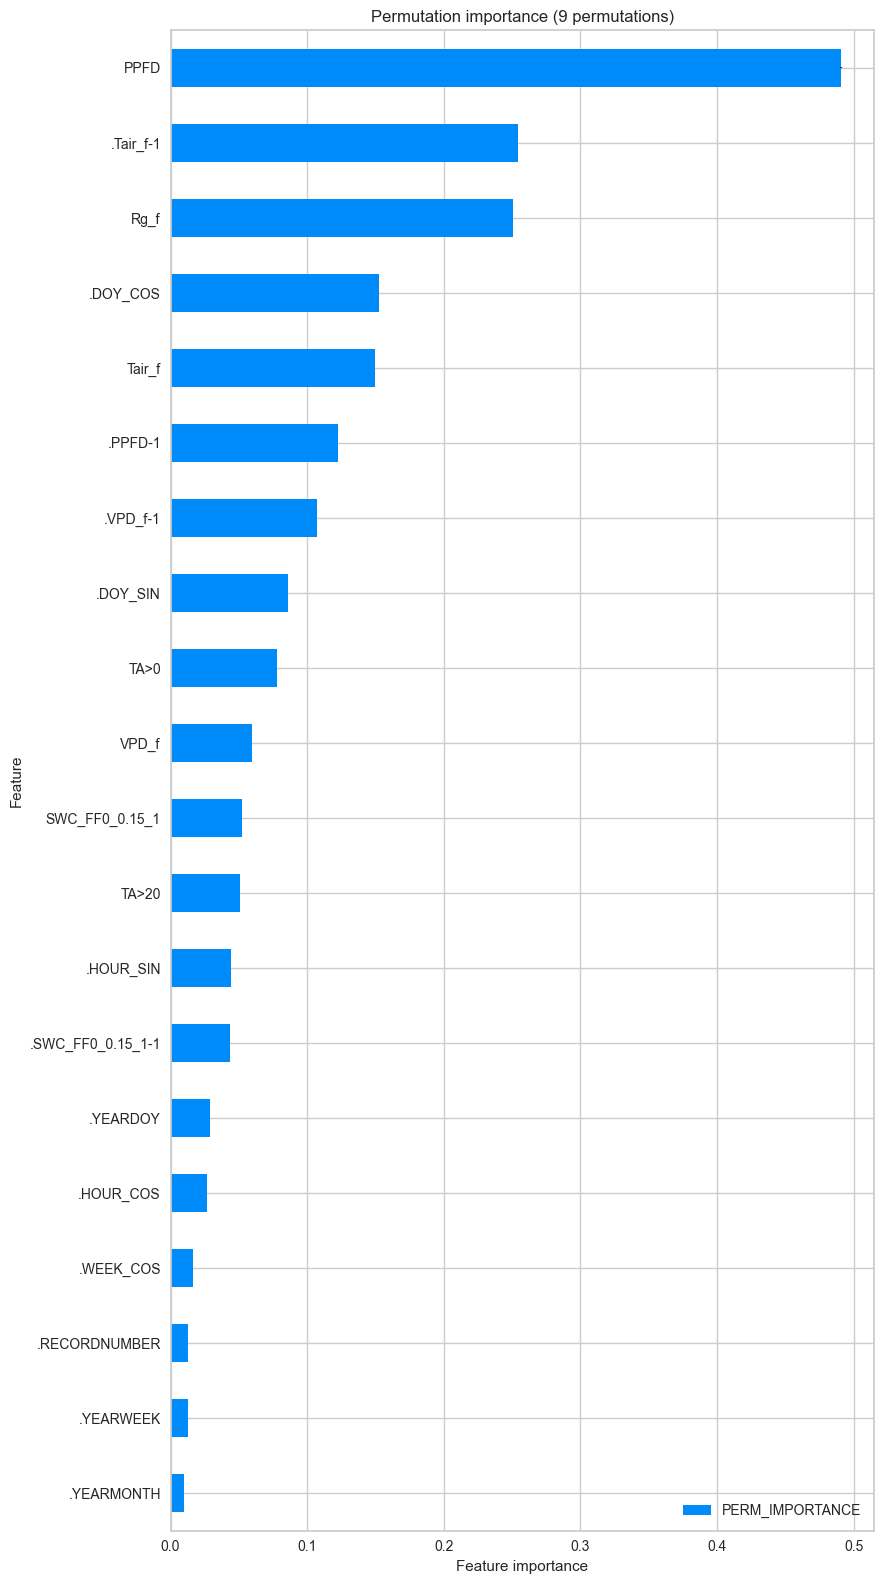

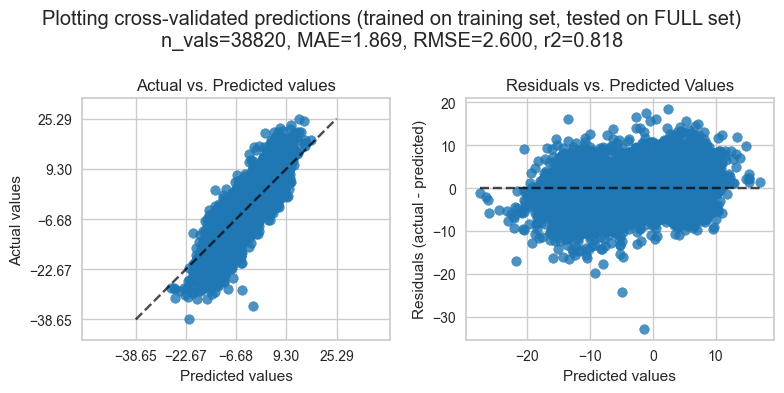

>>> Predicting target NEE_CUT_REF_orig where all features are available ... predicted 162851 records.
>>> Collecting results for final model ...
>>> Filling 124031 missing records in target with predictions from final model ...
>>> Storing gap-filled time series in variable NEE_CUT_REF_orig_gfXG ...
>>> Restoring original timestamp in results ...

Gap-filling 12445 remaining missing records in NEE_CUT_REF_orig_gfXG using fallback model ...
>>> Fallback model is trained on NEE_CUT_REF_orig_gfXG and timestamp info ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] (ONLY FALLBACK)
[0]	validation_0-rmse:3.85910	validation_1-rmse:3.85910
[1]	validation_0-rmse:3.19926	validation_1-rmse:3.19926
[2]	validation_0-rmse:2.81296	validation_1-rmse:2.81296
[3]	validation_0-rmse:

In [16]:
xgbts.fillgaps(showplot_scores=True, showplot_importance=True)

In [17]:
xgbts.report_gapfilling()


GAP-FILLING RESULTS

Model scores and feature importances were calculated from high-quality predicted targets (124031 values, NEE_CUT_REF_orig_gfXG where flag=1) in comparison to observed targets (38820 values, NEE_CUT_REF_orig).

## TARGET
- first timestamp:  2013-01-01 00:15:00
- last timestamp:  2022-12-31 23:45:00
- potential number of values: 175296 values)
- target column (observed):  NEE_CUT_REF_orig
- missing records (observed):  136476 (cross-check from flag: 136476)
- target column (gap-filled):  NEE_CUT_REF_orig_gfXG  (175296 values)
- missing records (gap-filled):  0
- gap-filling flag: FLAG_NEE_CUT_REF_orig_gfXG_ISFILLED
  > flag 0 ... observed targets (38820 values)
  > flag 1 ... targets gap-filled with high-quality, all features available (124031 values)
  > flag 2 ... targets gap-filled with fallback (12445 values)

## FEATURE IMPORTANCES
- names of features used in model:  ['PPFD', '.Tair_f-1', 'Rg_f', '.DOY_COS', 'Tair_f', '.PPFD-1', '.VPD_f-1', '.DOY_SIN', 'TA>0', 

</br>

## Attributes
A lot more information about feature reduction, training and testing, model building and gap-filling is available via the class attributes.

In [18]:
xgbts.feature_importances_

,PERM_IMPORTANCE,PERM_SD
PPFD,0.490317,0.006117
.Tair_f-1,0.254009,0.003088
Rg_f,0.250826,0.002570
.DOY_COS,0.152472,0.000668
Tair_f,0.149314,0.001935
.PPFD-1,0.122802,0.001497
.VPD_f-1,0.107513,0.001431
.DOY_SIN,0.086279,0.001247
TA>0,0.077592,0.001151
VPD_f,0.059547,0.000858


In [19]:
xgbts.feature_importances_reduction_

,PERM_IMPORTANCE,PERM_SD
PPFD,0.569436,0.003739
Rg_f,0.300630,0.001477
.Tair_f-1,0.258572,0.002258
.VPD_f-1,0.241383,0.003095
.DOY_COS,0.136796,0.001667
Tair_f,0.136032,0.001763
.PPFD-1,0.116557,0.001945
TA>0,0.085884,0.001047
VPD_f,0.083007,0.000811
.DOY_SIN,0.067341,0.001598


In [20]:
xgbts.feature_importances_traintest_

,PERM_IMPORTANCE,PERM_SD
PPFD,0.469389,0.006976
Rg_f,0.240586,0.003844
.Tair_f-1,0.238487,0.005395
Tair_f,0.144171,0.004518
.DOY_COS,0.137697,0.003040
.PPFD-1,0.108962,0.001547
.VPD_f-1,0.094906,0.002693
.DOY_SIN,0.078239,0.003276
TA>0,0.066721,0.002366
VPD_f,0.048886,0.001807


In [21]:
xgbts.gapfilling_df_

,.PREDICTIONS_FULLMODEL,NEE_CUT_REF_orig,.GAP_PREDICTIONS,FLAG_NEE_CUT_REF_orig_gfXG_ISFILLED,NEE_CUT_REF_orig_gfXG,.PREDICTIONS_FALLBACK,.GAPFILLED_CUMULATIVE,.PREDICTIONS
TIMESTAMP_MIDDLE,,,,,,,,
2013-01-01 00:15:00,NaN,NaN,NaN,2.0,1.295755,1.295755,1.295755,1.295755
2013-01-01 00:45:00,-0.013208,NaN,-0.013208,1.0,-0.013208,1.295755,1.282546,-0.013208
2013-01-01 01:15:00,-0.780887,NaN,-0.780887,1.0,-0.780887,1.014821,0.501659,-0.780887
2013-01-01 01:45:00,0.450344,0.538,NaN,0.0,0.538000,1.014821,1.039659,0.450344
2013-01-01 02:15:00,-2.454467,NaN,-2.454467,1.0,-2.454467,1.422202,-1.414807,-2.454467
...,...,...,...,...,...,...,...,...
2022-12-31 21:45:00,2.689172,NaN,2.689172,1.0,2.689172,2.686768,-63276.626289,2.689172
2022-12-31 22:15:00,2.488476,3.518,NaN,0.0,3.518000,2.731444,-63273.108289,2.488476
2022-12-31 22:45:00,2.202766,NaN,2.202766,1.0,2.202766,2.731444,-63270.905523,2.202766


In [22]:
xgbts.model_

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.3, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=99,
             n_jobs=-1, num_parallel_tree=None, ...)

In [23]:
xgbts.accepted_features_

['PPFD',
 'Rg_f',
 '.Tair_f-1',
 '.VPD_f-1',
 '.DOY_COS',
 'Tair_f',
 '.PPFD-1',
 'TA>0',
 'VPD_f',
 '.DOY_SIN',
 'TA>20',
 'SWC_FF0_0.15_1',
 '.HOUR_SIN',
 '.YEARDOY',
 '.YEARWEEK',
 '.SWC_FF0_0.15_1-1',
 '.HOUR_COS',
 '.RECORDNUMBER',
 '.YEARMONTH',
 '.WEEK_COS']

In [24]:
xgbts.rejected_features_

['DAYTIME',
 'NIGHTTIME',
 '.YEAR',
 '.SEASON_SIN',
 '.SEASON_COS',
 '.MONTH_SIN',
 '.MONTH_COS',
 '.WEEK_SIN']

In [25]:
xgbts.scores_

{'mae': 1.8687915705469054,
 'medae': np.float64(1.3659579868316654),
 'mse': 6.758158678001552,
 'rmse': 2.599645875499498,
 'mape': 262257315790.37543,
 'maxe': np.float64(32.81777895736694),
 'r2': 0.817981073669044}

In [26]:
xgbts.scores_traintest_

{'mae': 2.2142095150929317,
 'medae': np.float64(1.604416216850281),
 'mse': 9.661112559832171,
 'rmse': 3.108233028560145,
 'mape': 219579110459.27676,
 'maxe': np.float64(32.81777895736694),
 'r2': 0.7393577742941653}

In [27]:
xgbts.traintest_details_.keys()

dict_keys(['train_df', 'test_df', 'test_size', 'X_names', 'model'])

</br>

## Result

In [28]:
gapfilled = xgbts.get_gapfilled_target()
gapfilled

TIMESTAMP_MIDDLE
2013-01-01 00:15:00    1.295755
2013-01-01 00:45:00   -0.013208
2013-01-01 01:15:00   -0.780887
2013-01-01 01:45:00    0.538000
2013-01-01 02:15:00   -2.454467
                         ...   
2022-12-31 21:45:00    2.689172
2022-12-31 22:15:00    3.518000
2022-12-31 22:45:00    2.202766
2022-12-31 23:15:00    3.135547
2022-12-31 23:45:00    2.083491
Freq: 30min, Name: NEE_CUT_REF_orig_gfXG, Length: 175296, dtype: float64

In [29]:
flag = xgbts.get_flag()
flag

TIMESTAMP_MIDDLE
2013-01-01 00:15:00    2.0
2013-01-01 00:45:00    1.0
2013-01-01 01:15:00    1.0
2013-01-01 01:45:00    0.0
2013-01-01 02:15:00    1.0
                      ... 
2022-12-31 21:45:00    1.0
2022-12-31 22:15:00    0.0
2022-12-31 22:45:00    1.0
2022-12-31 23:15:00    1.0
2022-12-31 23:45:00    1.0
Freq: 30min, Name: FLAG_NEE_CUT_REF_orig_gfXG_ISFILLED, Length: 175296, dtype: float64

In [30]:
gapfilling_df = xgbts.gapfilling_df_
gapfilling_df

,.PREDICTIONS_FULLMODEL,NEE_CUT_REF_orig,.GAP_PREDICTIONS,FLAG_NEE_CUT_REF_orig_gfXG_ISFILLED,NEE_CUT_REF_orig_gfXG,.PREDICTIONS_FALLBACK,.GAPFILLED_CUMULATIVE,.PREDICTIONS
TIMESTAMP_MIDDLE,,,,,,,,
2013-01-01 00:15:00,NaN,NaN,NaN,2.0,1.295755,1.295755,1.295755,1.295755
2013-01-01 00:45:00,-0.013208,NaN,-0.013208,1.0,-0.013208,1.295755,1.282546,-0.013208
2013-01-01 01:15:00,-0.780887,NaN,-0.780887,1.0,-0.780887,1.014821,0.501659,-0.780887
2013-01-01 01:45:00,0.450344,0.538,NaN,0.0,0.538000,1.014821,1.039659,0.450344
2013-01-01 02:15:00,-2.454467,NaN,-2.454467,1.0,-2.454467,1.422202,-1.414807,-2.454467
...,...,...,...,...,...,...,...,...
2022-12-31 21:45:00,2.689172,NaN,2.689172,1.0,2.689172,2.686768,-63276.626289,2.689172
2022-12-31 22:15:00,2.488476,3.518,NaN,0.0,3.518000,2.731444,-63273.108289,2.488476
2022-12-31 22:45:00,2.202766,NaN,2.202766,1.0,2.202766,2.731444,-63270.905523,2.202766


</br>

## Plot

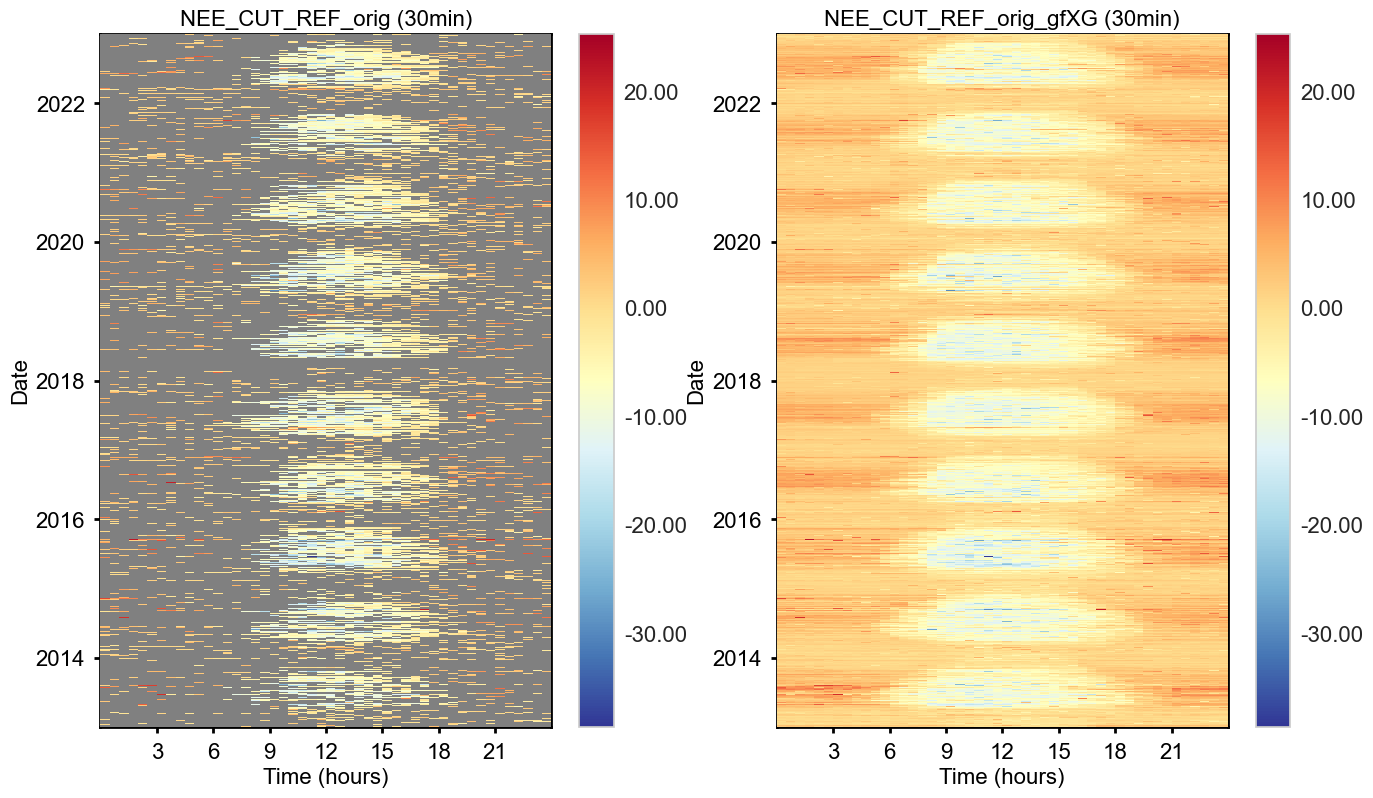

In [31]:
fig, axs = plt.subplots(ncols=2, figsize=(16, 9))
HeatmapDateTime(series=df[TARGET_COL], ax=axs[0]).plot()
HeatmapDateTime(series=gapfilled, ax=axs[1]).plot()

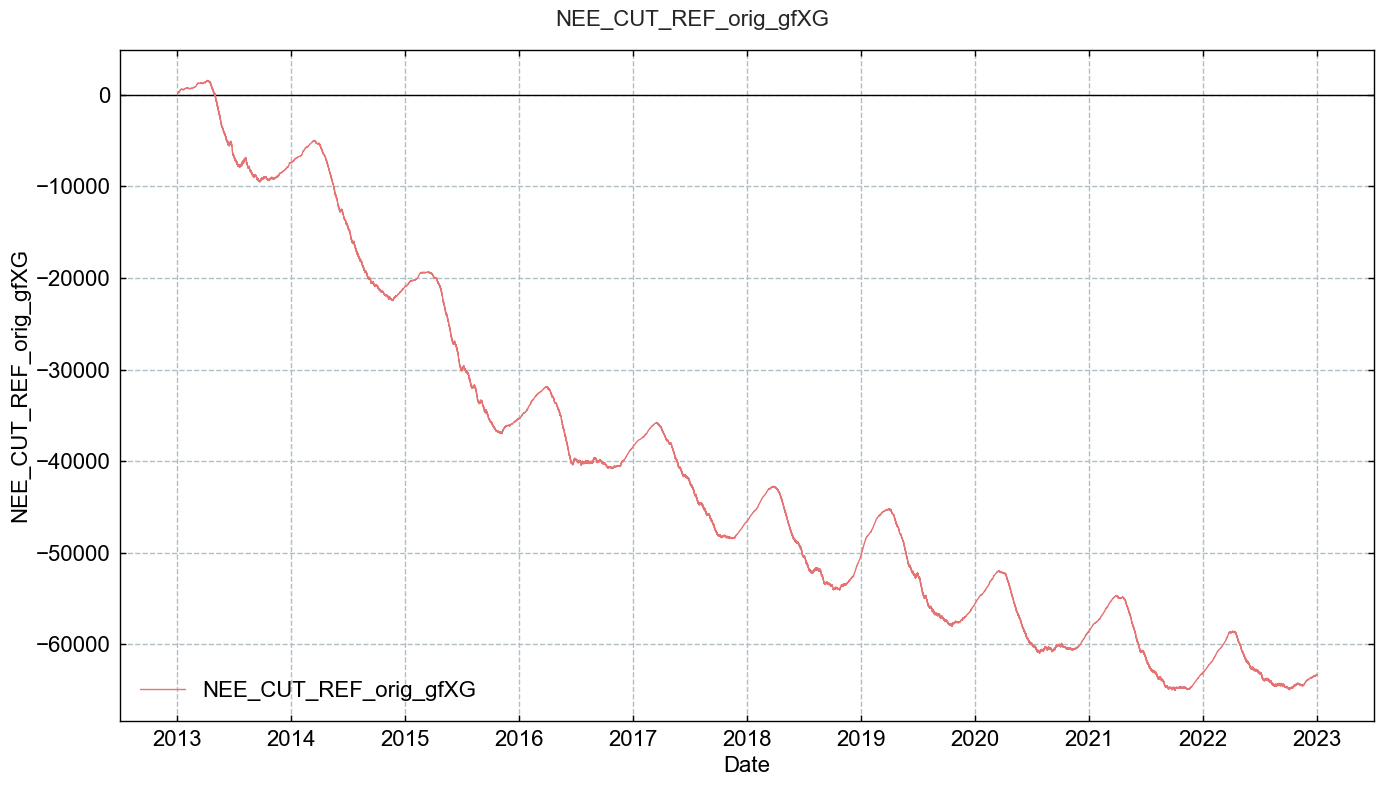

In [32]:
TimeSeries(gapfilled.cumsum()).plot();

</br>

# **End of notebook**
Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [33]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-01-12 21:57:32
